# **Oil Price Time Series Forecasting: A Comparative Study of ARMA and LSTM Models**

## **MSc Data Science Research Assignment**


**Date:** February 2026

**Dataset:** Daily Oil Prices (September 2024 - February 2026)

---

### **Executive Summary**

This notebook presents a comprehensive time series analysis of daily oil price data, implementing both traditional statistical approaches (ARIMA) and modern deep learning methodologies (LSTM neural networks). The analysis encompasses exploratory data analysis, stationarity testing, model selection via grid search, diagnostic checking, and 24-month forecasting with uncertainty quantification.

In [3]:
# =============================================================================
# CELL 1: ENVIRONMENT SETUP AND LIBRARY IMPORTS
# =============================================================================

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Core data manipulation
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from itertools import product

# Statistical analysis
from scipy import stats
from scipy.stats import jarque_bera, normaltest

# Time series analysis
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Machine Learning - TensorFlow/Keras for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10

print("Environment configured successfully.\n")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Environment configured successfully.

TensorFlow version: 2.19.0
Pandas version: 2.2.2
NumPy version: 1.26.4


---

## **PART 1: DATA EXPLORATION AND PREPROCESSING**

### **Section 1.1: Data Loading and Validation**

In [4]:
# =============================================================================
# CELL 2: DATA LOADING AND INITIAL VALIDATION
# =============================================================================

def load_and_validate_oil_data(filepath):
    """
    Load oil price data with comprehensive validation checks.
    
    Parameters:
    -----------
    filepath : str
        Path to the CSV file containing oil price data
        
    Returns:
    --------
    pd.DataFrame
        Validated and cleaned time series dataframe
    """
    # Load raw data
    df = pd.read_csv(filepath)
    
    # Standardize column names
    df.columns = df.columns.str.strip().str.lower()
    
    # Parse dates with explicit format handling
    df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y', dayfirst=True)
    
    # Sort chronologically
    df = df.sort_values('date').reset_index(drop=True)
    
    # Rename price column for consistency
    if 'price (dollars)' in df.columns:
        df = df.rename(columns={'price (dollars)': 'price'})
    
    # Set date as index
    df.set_index('date', inplace=True)
    
    # Data quality checks
    print("=" * 60)
    print("DATA VALIDATION REPORT")
    print("=" * 60)
    print(f"\nDataset Shape: {df.shape[0]} observations, {df.shape[1]} variable(s)")
    print(f"Date Range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
    
    # Check for missing values
    missing_count = df['price'].isnull().sum()
    print(f"\nMissing Values: {missing_count}")
    
    # Check for duplicate dates
    duplicate_dates = df.index.duplicated().sum()
    print(f"Duplicate Dates: {duplicate_dates}")
    
    # Check for date continuity
    expected_days = (df.index.max() - df.index.min()).days + 1
    actual_days = len(df)
    print(f"\nDate Continuity:")
    print(f"  Expected days: {expected_days}")
    print(f"  Actual days: {actual_days}")
    print(f"  Missing days: {expected_days - actual_days}")
    
    # Basic statistics
    print(f"\nDescriptive Statistics:")
    print(f"  Mean Price: ${df['price'].mean():.2f}")
    print(f"  Std Dev: ${df['price'].std():.2f}")
    print(f"  Min Price: ${df['price'].min():.2f}")
    print(f"  Max Price: ${df['price'].max():.2f}")
    
    # Detect potential outliers using IQR method
    Q1 = df['price'].quantile(0.25)
    Q3 = df['price'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
    print(f"\nOutlier Detection (IQR method): {len(outliers)} potential outlier(s)")
    
    print("=" * 60)
    
    return df

# Load the data
oil_data = load_and_validate_oil_data('oil_prices_2426.csv')
oil_data.head(10)

DATA VALIDATION REPORT

Dataset Shape: 500 observations, 1 variable(s)
Date Range: 2024-09-21 to 2026-02-02

Missing Values: 0
Duplicate Dates: 0

Date Continuity:
  Expected days: 500
  Actual days: 500
  Missing days: 0

Descriptive Statistics:
  Mean Price: $75.87
  Std Dev: $42.91
  Min Price: $16.48
  Max Price: $158.78

Outlier Detection (IQR method): 0 potential outlier(s)


,price
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21
2024-09-26,33.38
2024-09-27,34.08
2024-09-28,34.43
2024-09-29,35.83


### **Section 1.2: Exploratory Data Analysis - Visualisation**

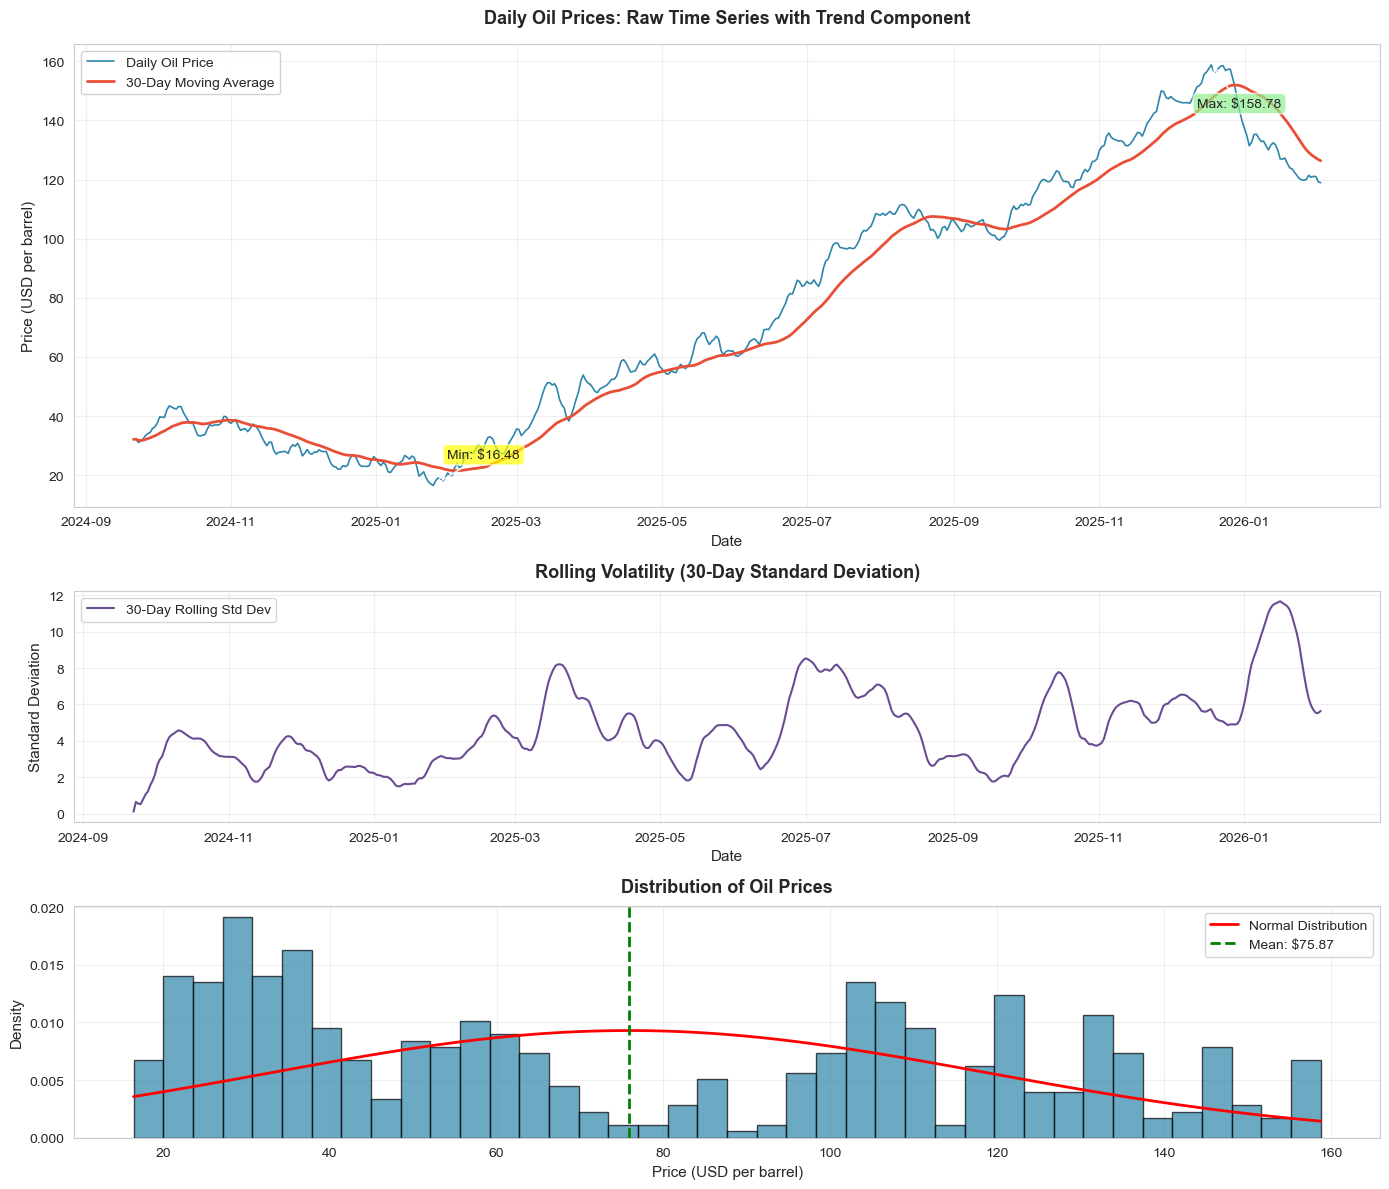

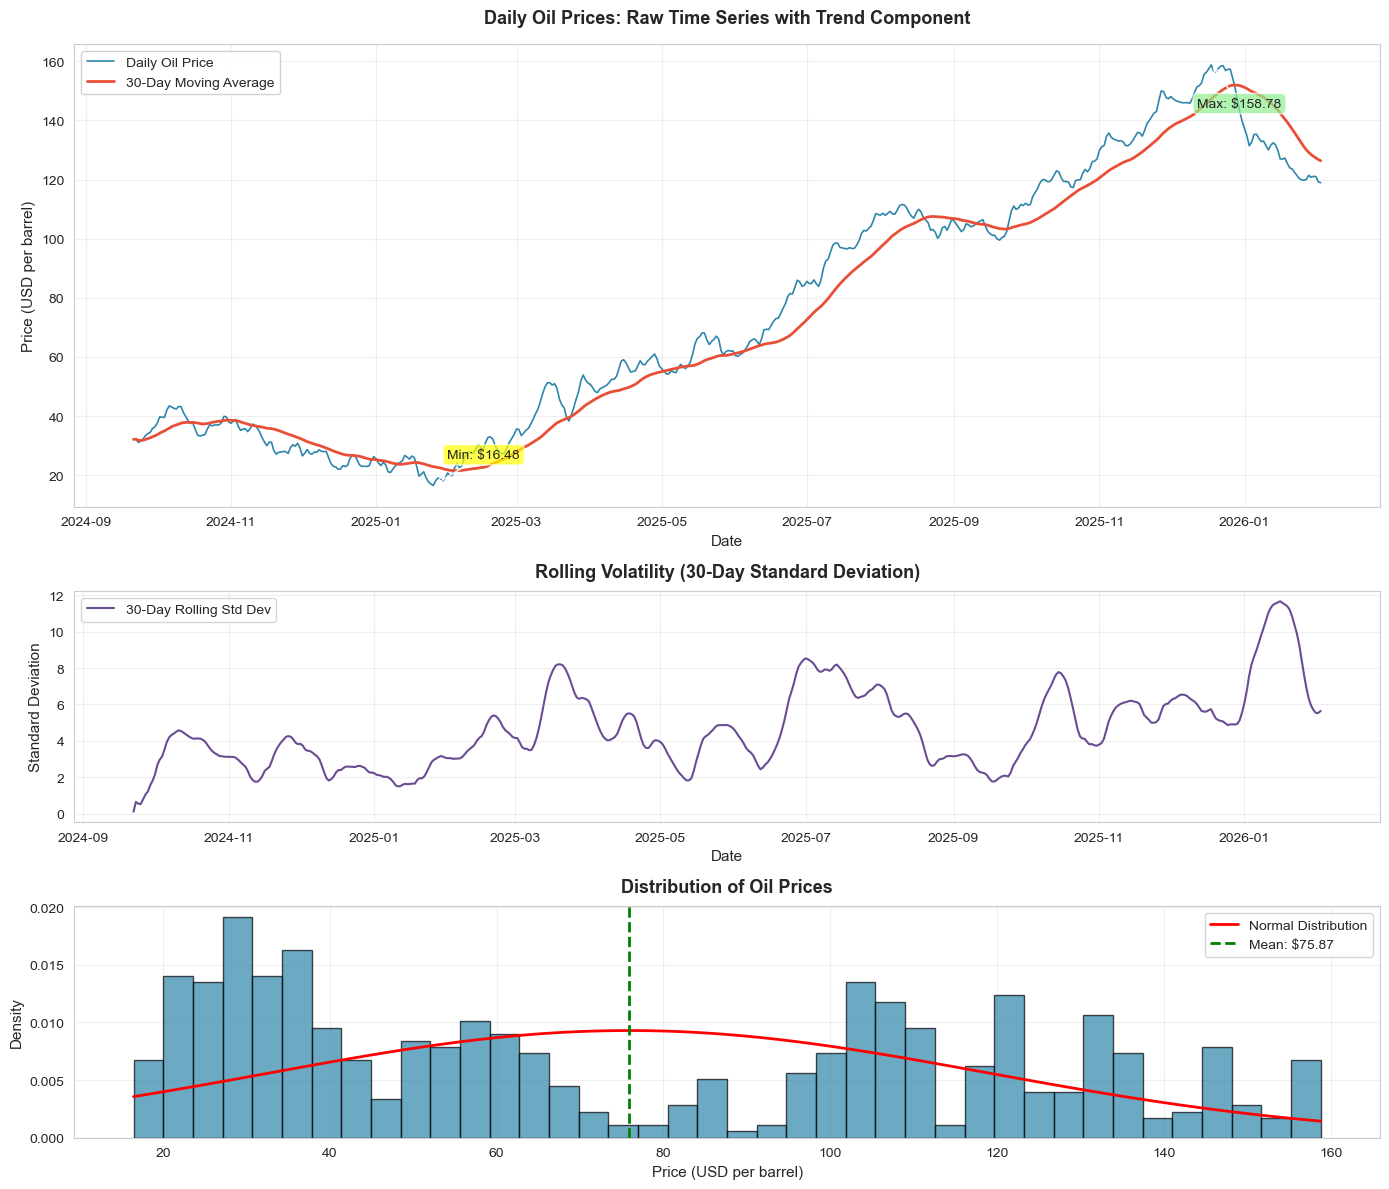

In [5]:
# =============================================================================
# CELL 3: EXPLORATORY DATA VISUALISATION
# =============================================================================

def plot_time_series_overview(df):
    """
    Create comprehensive exploratory visualizations of the oil price series.
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1, 1]})
    
    # Plot 1: Raw time series with trend
    ax1 = axes[0]
    ax1.plot(df.index, df['price'], color='#2E86AB', linewidth=1.2, label='Daily Oil Price')
    
    # Add 30-day rolling mean
    rolling_mean = df['price'].rolling(window=30, min_periods=1).mean()
    ax1.plot(df.index, rolling_mean, color='#E94F37', linewidth=2, label='30-Day Moving Average')
    
    # Formatting
    ax1.set_title('Daily Oil Prices: Raw Time Series with Trend Component', fontweight='bold', pad=15)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price (USD per barrel)')
    ax1.legend(loc='upper left', framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    
    # Add annotations for key events
    min_price_idx = df['price'].idxmin()
    max_price_idx = df['price'].idxmax()
    ax1.annotate(f'Min: ${df.loc[min_price_idx, "price"]:.2f}',
                xy=(min_price_idx, df.loc[min_price_idx, 'price']),
                xytext=(10, 20), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    ax1.annotate(f'Max: ${df.loc[max_price_idx, "price"]:.2f}',
                xy=(max_price_idx, df.loc[max_price_idx, 'price']),
                xytext=(-10, -30), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    # Plot 2: Rolling statistics
    ax2 = axes[1]
    rolling_std = df['price'].rolling(window=30, min_periods=1).std()
    ax2.plot(df.index, rolling_std, color='#6A4C93', linewidth=1.5, label='30-Day Rolling Std Dev')
    ax2.set_title('Rolling Volatility (30-Day Standard Deviation)', fontweight='bold', pad=10)
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Standard Deviation')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Distribution of prices
    ax3 = axes[2]
    ax3.hist(df['price'], bins=40, color='#2E86AB', edgecolor='black', alpha=0.7, density=True)
    
    # Overlay normal distribution for comparison
    mu, sigma = df['price'].mean(), df['price'].std()
    x = np.linspace(df['price'].min(), df['price'].max(), 100)
    ax3.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
    ax3.axvline(mu, color='green', linestyle='--', linewidth=2, label=f'Mean: ${mu:.2f}')
    
    ax3.set_title('Distribution of Oil Prices', fontweight='bold', pad=10)
    ax3.set_xlabel('Price (USD per barrel)')
    ax3.set_ylabel('Density')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('eda_overview.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# Generate EDA plots
plot_time_series_overview(oil_data)

---

## **PART 2: STATIONARITY ANALYSIS**

### **Section 2.1: Statistical Stationarity Testing**

STATIONARITY ANALYSIS: RAW OIL PRICE SERIES


AUGMENTED DICKEY-FULLER TEST: Raw Oil Prices

Test Statistic: -0.546234
p-value: 0.882674

Critical Values:
  1%: -3.4440
  5%: -2.8676
  10%: -2.5700

Conclusion: FAIL TO REJECT H0 at α=0.05: Series is NON-STATIONARY


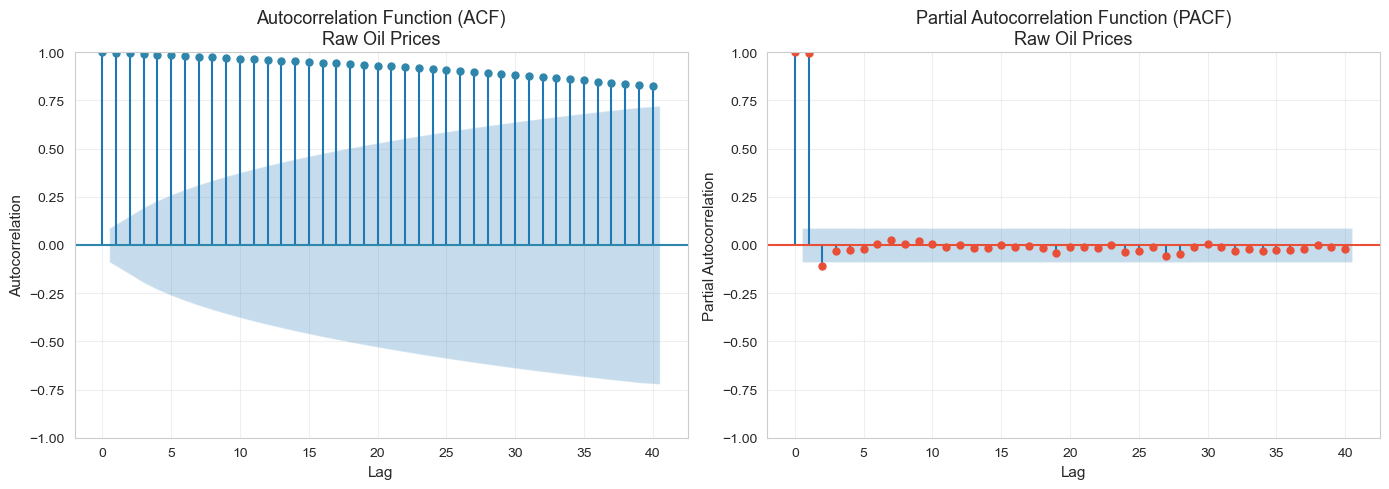

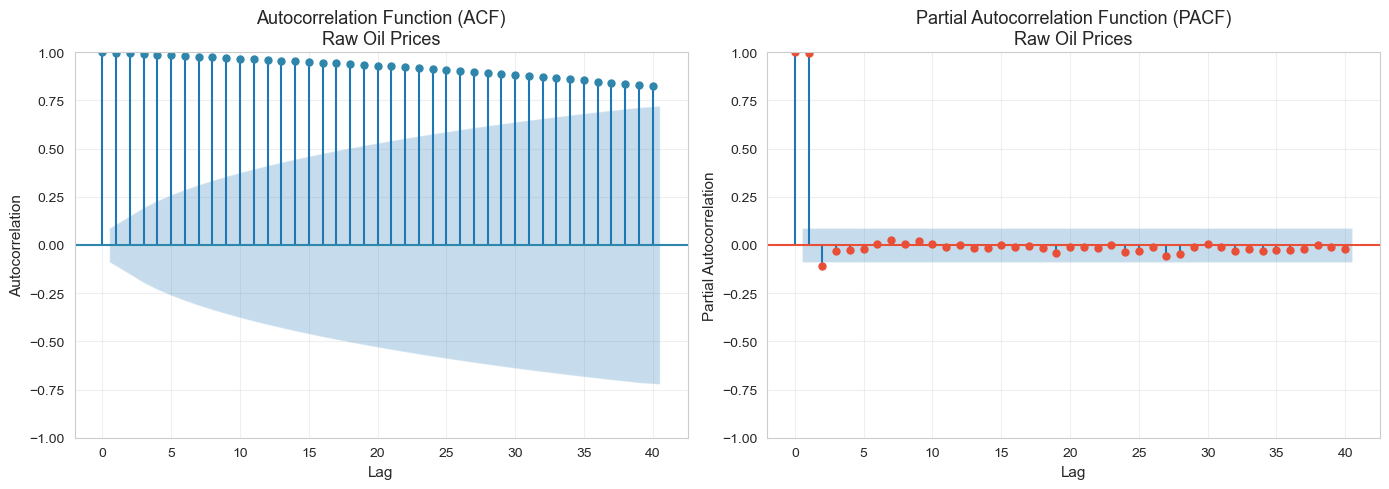

In [6]:
# =============================================================================
# CELL 4: STATIONARITY TESTING FRAMEWORK
# =============================================================================

def perform_adf_test(series, series_name='Time Series'):
    """
    Conduct Augmented Dickey-Fuller test for unit root / stationarity.
    
    The ADF test examines the null hypothesis that the series contains
    a unit root (non-stationary). Rejection of H0 suggests stationarity.
    
    Parameters:
    -----------
    series : pd.Series
        Time series to test
    series_name : str
        Descriptive name for the series
        
    Returns:
    --------
    dict
        Test results and interpretation
    """
    result = adfuller(series.dropna(), autolag='AIC')
    
    print(f"\n{'='*60}")
    print(f"AUGMENTED DICKEY-FULLER TEST: {series_name}")
    print('='*60)
    
    # Test statistic
    print(f"\nTest Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print(f"\nCritical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")
    
    # Interpretation
    alpha = 0.05
    if result[1] < alpha:
        conclusion = f"REJECT H0 at α={alpha}: Series is STATIONARY"
        is_stationary = True
    else:
        conclusion = f"FAIL TO REJECT H0 at α={alpha}: Series is NON-STATIONARY"
        is_stationary = False
    
    print(f"\nConclusion: {conclusion}")
    print('='*60)
    
    return {
        'test_statistic': result[0],
        'p_value': result[1],
        'is_stationary': is_stationary,
        'critical_values': result[4]
    }

def plot_acf_pacf_detailed(series, series_name='Series', lags=40):
    """
    Generate detailed ACF and PACF plots with confidence intervals.
    
    These plots guide ARMA parameter selection:
    - ACF identifies MA(q) order
    - PACF identifies AR(p) order
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ACF Plot
    ax1 = axes[0]
    plot_acf(series.dropna(), lags=lags, ax=ax1, color='#2E86AB',
             title=f'Autocorrelation Function (ACF)\n{series_name}')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('Lag')
    ax1.set_ylabel('Autocorrelation')
    
    # PACF Plot
    ax2 = axes[1]
    plot_pacf(series.dropna(), lags=lags, ax=ax2, color='#E94F37',
              title=f'Partial Autocorrelation Function (PACF)\n{series_name}')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('Lag')
    ax2.set_ylabel('Partial Autocorrelation')
    
    plt.tight_layout()
    plt.savefig(f'acf_pacf_{series_name.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# Test stationarity of raw series
print("STATIONARITY ANALYSIS: RAW OIL PRICE SERIES\n")
adf_raw = perform_adf_test(oil_data['price'], 'Raw Oil Prices')

# Generate ACF/PACF for raw series
plot_acf_pacf_detailed(oil_data['price'], 'Raw Oil Prices')

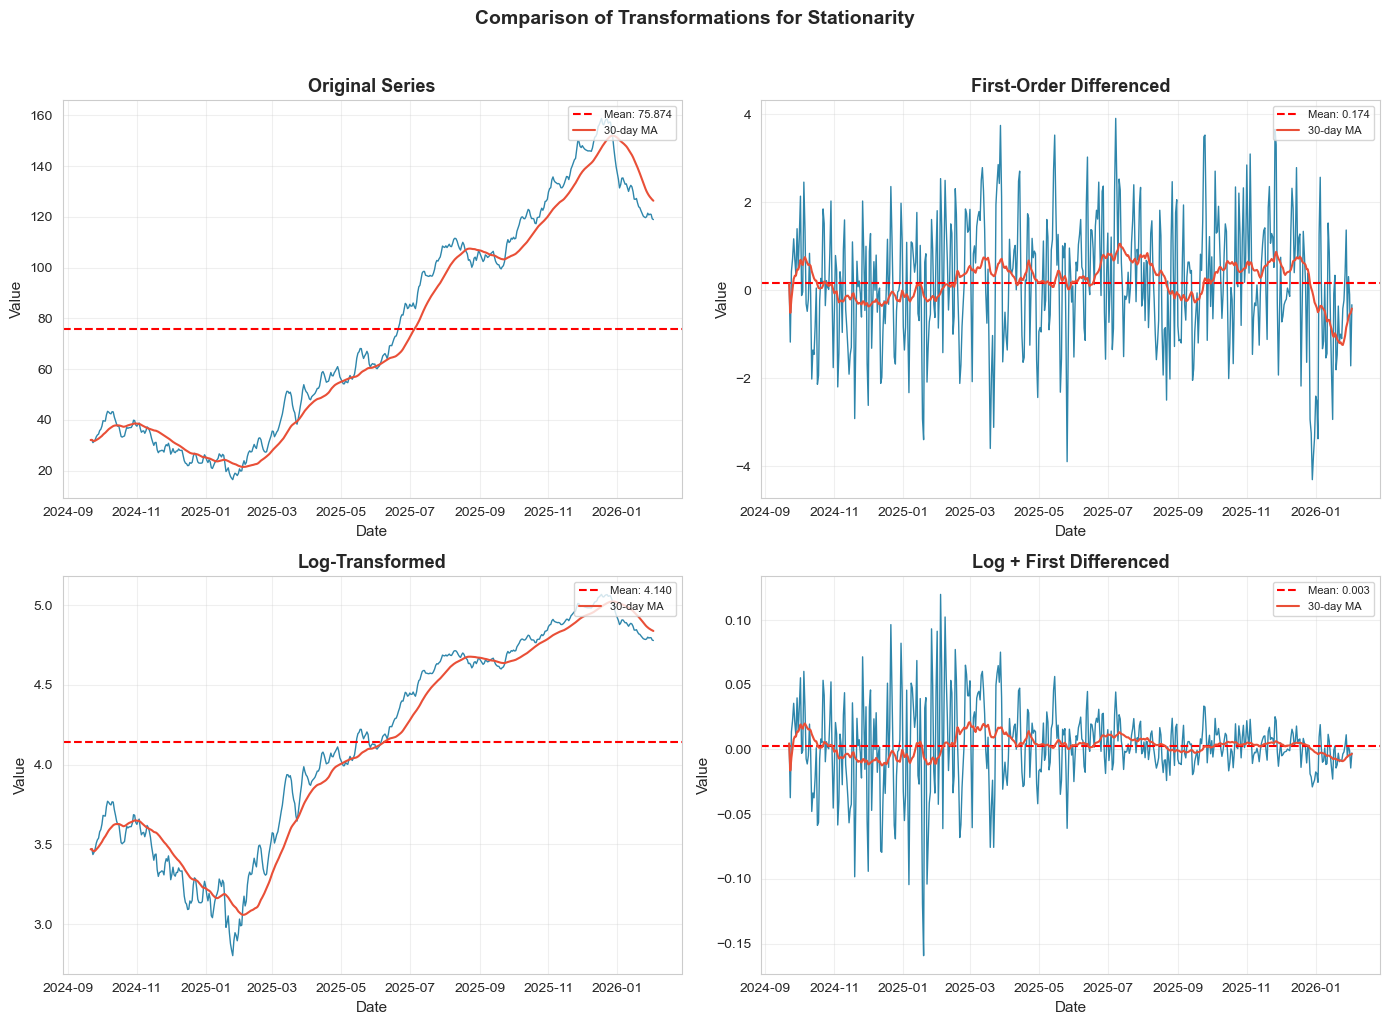




AUGMENTED DICKEY-FULLER TEST: First-Order Differenced

Test Statistic: -4.541460
p-value: 0.000165

Critical Values:
  1%: -3.4440
  5%: -2.8676
  10%: -2.5700

Conclusion: REJECT H0 at α=0.05: Series is STATIONARY



AUGMENTED DICKEY-FULLER TEST: Log + First Differenced

Test Statistic: -6.341003
p-value: 0.000000

Critical Values:
  1%: -3.4439
  5%: -2.8675
  10%: -2.5700

Conclusion: REJECT H0 at α=0.05: Series is STATIONARY


In [7]:
# =============================================================================
# CELL 5: DIFFERENCING AND TRANSFORMATION
# =============================================================================

def apply_differencing(df, price_col='price'):
    """
    Apply differencing transformations to achieve stationarity.
    
    Differencing is a technique to remove trends and make a non-stationary
    time series stationary by computing the difference between consecutive
    observations.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with time series
    price_col : str
        Name of the price column
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with differenced series added
    """
    df = df.copy()
    
    # First-order difference (removes linear trends)
    df['price_diff1'] = df[price_col].diff(1)
    
    # Second-order difference (for additional differencing if needed)
    df['price_diff2'] = df[price_col].diff(2)
    
    # Log transformation (stabilizes variance for multiplicative patterns)
    df['log_price'] = np.log(df[price_col])
    df['log_price_diff1'] = df['log_price'].diff(1)
    
    return df

def compare_transformations(df):
    """
    Visual comparison of original and transformed series.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    transformations = [
        ('price', 'Original Series'),
        ('price_diff1', 'First-Order Differenced'),
        ('log_price', 'Log-Transformed'),
        ('log_price_diff1', 'Log + First Differenced')
    ]
    
    for idx, (col, title) in enumerate(transformations):
        ax = axes[idx // 2, idx % 2]
        data = df[col].dropna()
        
        ax.plot(data.index, data.values, color='#2E86AB', linewidth=1)
        ax.axhline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.3f}')
        
        # Add rolling mean
        rolling = data.rolling(window=30, min_periods=1).mean()
        ax.plot(rolling.index, rolling.values, color='#E94F37', linewidth=1.5, label='30-day MA')
        
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Value')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Comparison of Transformations for Stationarity', fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('transformation_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# Apply transformations
oil_data = apply_differencing(oil_data)

# Visual comparison
compare_transformations(oil_data)

# Test stationarity of differenced series
print("\n")
adf_diff1 = perform_adf_test(oil_data['price_diff1'], 'First-Order Differenced')

print("\n")
adf_logdiff = perform_adf_test(oil_data['log_price_diff1'], 'Log + First Differenced')


Autocorrelation Analysis of Stationary Series



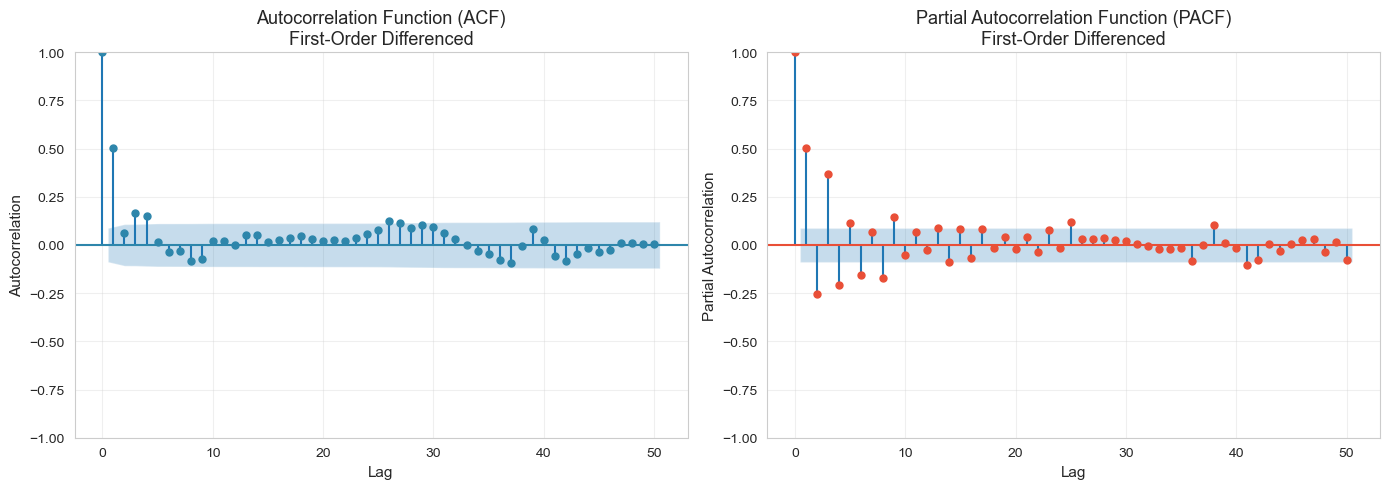


STATIONARITY TEST SUMMARY

Transformation                   ADF Statistic      p-value  Stationary?
------------------------------------------------------------
Original Series                        -0.5462     0.882674        False
First Differenced                      -4.5415     0.000165         True
Log + First Differenced                -6.3410     0.000000         True

Conclusion: The series requires first-order differencing (d=1) for stationarity.
This indicates a stochastic trend in the original oil price data.


In [8]:
# =============================================================================
# CELL 6: ACF/PACF OF STATIONARY SERIES
# =============================================================================

# Plot ACF/PACF for the stationary series (first-order differenced)
print("\nAutocorrelation Analysis of Stationary Series\n")
plot_acf_pacf_detailed(oil_data['price_diff1'], 'First-Order Differenced', lags=50)

# Summary of stationarity tests
print("\n" + "="*60)
print("STATIONARITY TEST SUMMARY")
print("="*60)
print(f"\n{'Transformation':<30} {'ADF Statistic':>15} {'p-value':>12} {'Stationary?':>12}")
print("-"*60)
print(f"{'Original Series':<30} {adf_raw['test_statistic']:>15.4f} {adf_raw['p_value']:>12.6f} {str(adf_raw['is_stationary']):>12}")
print(f"{'First Differenced':<30} {adf_diff1['test_statistic']:>15.4f} {adf_diff1['p_value']:>12.6f} {str(adf_diff1['is_stationary']):>12}")
print(f"{'Log + First Differenced':<30} {adf_logdiff['test_statistic']:>15.4f} {adf_logdiff['p_value']:>12.6f} {str(adf_logdiff['is_stationary']):>12}")
print("="*60)
print("\nConclusion: The series requires first-order differencing (d=1) for stationarity.")
print("This indicates a stochastic trend in the original oil price data.")

---

## **PART 3: ARMA/ARIMA MODELLING**

### **Section 3.1: Grid Search for Optimal Parameters**

In [9]:
# =============================================================================
# CELL 7: ARIMA GRID SEARCH WITH AIC CRITERION
# =============================================================================

def perform_arima_grid_search(series, p_range, d_range, q_range):
    """
    Exhaustive grid search for optimal ARIMA parameters using AIC.
    
    The Akaike Information Criterion (AIC) balances model fit with complexity,
    penalizing excessive parameters to avoid overfitting.
    
    Parameters:
    -----------
    series : pd.Series
        Time series to model
    p_range : list
        Range of AR orders to test
    d_range : list
        Range of differencing orders
    q_range : list
        Range of MA orders to test
        
    Returns:
    --------
    pd.DataFrame
        Results table sorted by AIC
    dict
        Best model parameters
    """
    
    results = []
    best_aic = float('inf')
    best_params = None
    best_model = None
    
    total_combinations = len(p_range) * len(d_range) * len(q_range)
    print(f"Performing grid search over {total_combinations} parameter combinations...\n")
    
    for idx, (p, d, q) in enumerate(product(p_range, d_range, q_range)):
        
        # Skip invalid combinations
        if p == 0 and q == 0 and d == 0:
            continue
            
        try:
            model = ARIMA(series, order=(p, d, q))
            fitted = model.fit()
            
            results.append({
                'p': p,
                'd': d,
                'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'log_likelihood': fitted.llf,
                'converged': fitted.mle_retvals.get('converged', True)
            })
            
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_params = {'p': p, 'd': d, 'q': q}
                best_model = fitted
                
            if (idx + 1) % 20 == 0:
                print(f"  Processed {(idx + 1)}/{total_combinations} combinations...\n")
                
        except Exception as e:
            results.append({
                'p': p,
                'd': d,
                'q': q,
                'AIC': np.nan,
                'BIC': np.nan,
                'log_likelihood': np.nan,
                'converged': False
            })
    
    # Convert to DataFrame and sort
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('AIC').reset_index(drop=True)
    
    print("\n" + "="*70)
    print("ARIMA GRID SEARCH RESULTS (Top 10 Models by AIC)")
    print("="*70)
    print(results_df.head(10).to_string(index=False))
    print("\n" + "="*70)
    print(f"\nOPTIMAL PARAMETERS: ARIMA({best_params['p']},{best_params['d']},{best_params['q']})")
    print(f"Minimum AIC: {best_aic:.4f}")
    print("="*70)
    
    return results_df, best_params, best_model

# Define parameter ranges as per assignment requirements
p_range = range(0, 9)   # p ∈ [0, 8]
d_range = range(0, 3)   # d ∈ [0, 2]
q_range = range(0, 9)   # q ∈ [0, 8]

# Execute grid search
results_table, optimal_params, optimal_arima = perform_arima_grid_search(
    oil_data['price'], p_range, d_range, q_range
)

Performing grid search over 243 parameter combinations...

  Processed 20/243 combinations...

  Processed 40/243 combinations...

  Processed 60/243 combinations...

  Processed 80/243 combinations...

  Processed 100/243 combinations...

  Processed 120/243 combinations...

  Processed 140/243 combinations...

  Processed 160/243 combinations...

  Processed 180/243 combinations...

  Processed 200/243 combinations...

  Processed 220/243 combinations...

  Processed 240/243 combinations...


ARIMA GRID SEARCH RESULTS (Top 10 Models by AIC)
 p  d  q         AIC         BIC  log_likelihood  converged
 2  2  7 1429.216571 1471.322572     -704.608286      False
 4  1  5 1429.771989 1471.898050     -704.885994      False
 0  1  5 1429.897917 1455.173554     -708.948958       True
 1  1  4 1430.457760 1455.733397     -709.228880       True
 4  1  8 1430.507906 1485.271786     -702.253953      False
 2  1  4 1430.851612 1460.339854     -708.425806       True
 5  1  5 1430.983812 1477.32247

### **Section 3.2: Model Diagnostics and Residual Analysis**

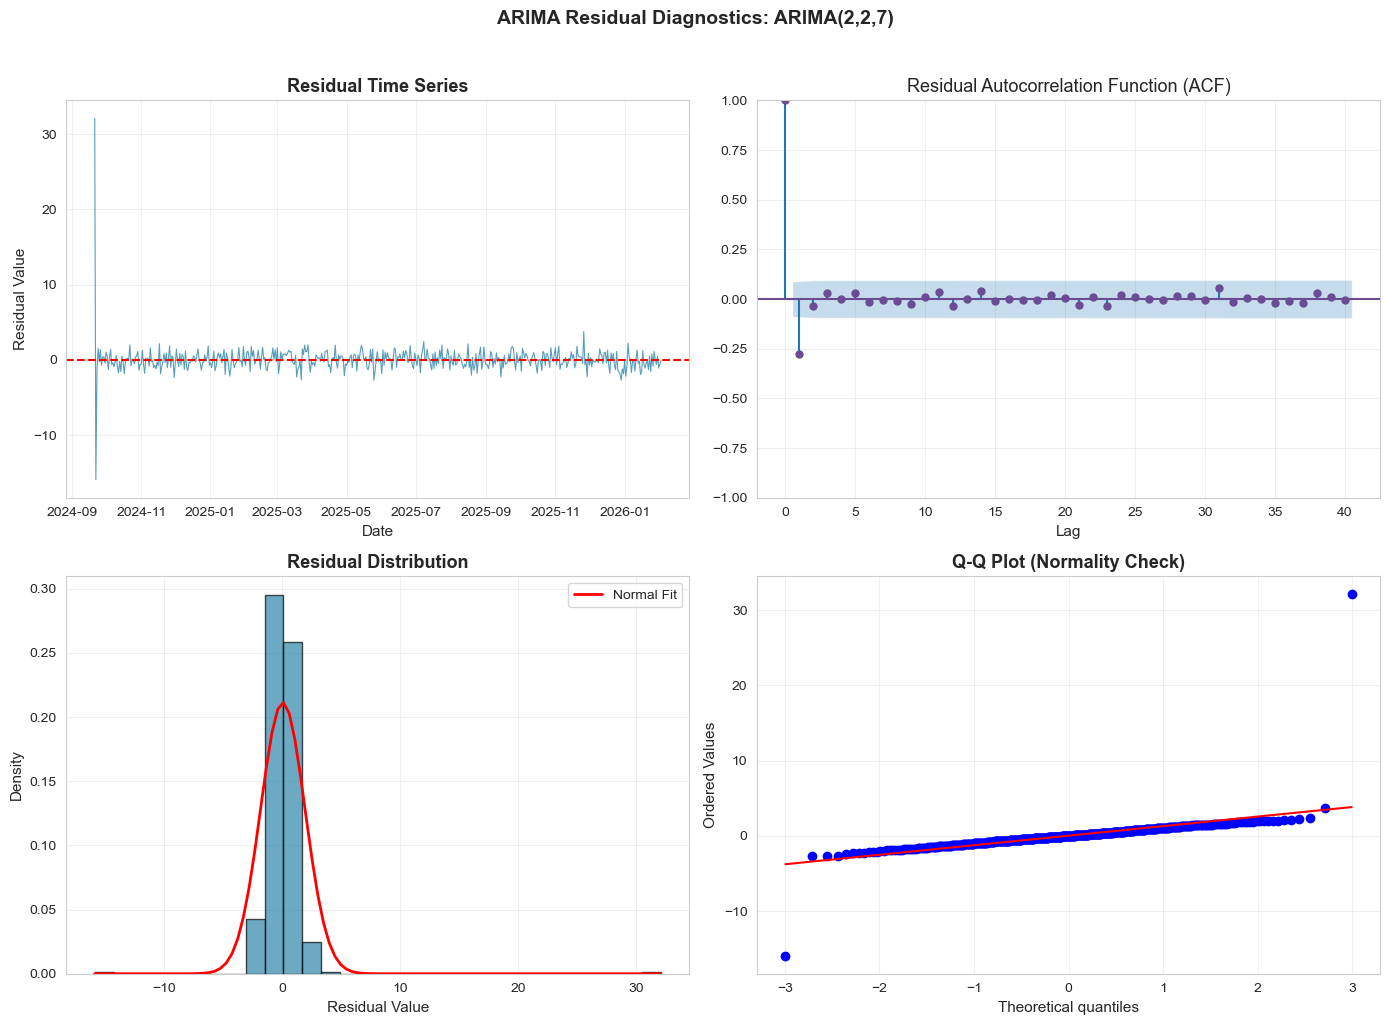


RESIDUAL DIAGNOSTIC TESTS: ARIMA(2,2,7)

Ljung-Box Test for Autocorrelation:
      lb_stat  lb_pvalue
10  40.274994   0.000015
20  42.736249   0.002215
30  44.469285   0.043217

Jarque-Bera Test for Normality:
  Statistic: 643709.8313
  p-value: 0.000000
  Interpretation: Non-normal at α=0.05

Residual Summary Statistics:
  Mean: 0.044833
  Std Dev: 1.8863
  Skewness: 8.6437
  Kurtosis: 176.7055


In [10]:
# =============================================================================
# CELL 8: RESIDUAL DIAGNOSTICS
# =============================================================================

def analyze_residuals(model, series_name='Model'):
    """
    Comprehensive residual analysis for ARIMA model diagnostics.
    
    Proper residual diagnostics verify that the model has captured
    all systematic patterns, leaving white noise residuals.
    
    Parameters:
    -----------
    model : ARIMA fitted results
    series_name : str
        Name for labeling
        
    Returns:
    --------
    dict
        Diagnostic test results
    """
    residuals = model.resid
    
    # Create diagnostic plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Residual time series
    ax1 = axes[0, 0]
    ax1.plot(residuals.index, residuals.values, color='#2E86AB', linewidth=0.8, alpha=0.8)
    ax1.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax1.set_title('Residual Time Series', fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Residual Value')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Residual ACF
    ax2 = axes[0, 1]
    plot_acf(residuals, lags=40, ax=ax2, color='#6A4C93',
             title='Residual Autocorrelation Function (ACF)')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('Lag')
    
    # Plot 3: Residual distribution
    ax3 = axes[1, 0]
    ax3.hist(residuals, bins=30, color='#2E86AB', edgecolor='black', alpha=0.7, density=True)
    
    # Overlay normal distribution
    mu, sigma = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 100)
    ax3.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Fit')
    ax3.set_title('Residual Distribution', fontweight='bold')
    ax3.set_xlabel('Residual Value')
    ax3.set_ylabel('Density')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Q-Q plot for normality
    ax4 = axes[1, 1]
    stats.probplot(residuals, dist="norm", plot=ax4)
    ax4.set_title('Q-Q Plot (Normality Check)', fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'ARIMA Residual Diagnostics: {series_name}', fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('arima_residual_diagnostics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Statistical tests
    print("\n" + "="*60)
    print(f"RESIDUAL DIAGNOSTIC TESTS: {series_name}")
    print("="*60)
    
    # Ljung-Box test for autocorrelation
    lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
    print("\nLjung-Box Test for Autocorrelation:")
    print(lb_test.to_string())
    
    # Jarque-Bera test for normality
    jb_stat, jb_pval = jarque_bera(residuals.dropna())
    print(f"\nJarque-Bera Test for Normality:")
    print(f"  Statistic: {jb_stat:.4f}")
    print(f"  p-value: {jb_pval:.6f}")
    print(f"  Interpretation: {'Normal' if jb_pval > 0.05 else 'Non-normal'} at α=0.05")
    
    # Summary statistics
    print(f"\nResidual Summary Statistics:")
    print(f"  Mean: {residuals.mean():.6f}")
    print(f"  Std Dev: {residuals.std():.4f}")
    print(f"  Skewness: {residuals.skew():.4f}")
    print(f"  Kurtosis: {residuals.kurtosis():.4f}")
    print("="*60)
    
    return {
        'ljung_box': lb_test,
        'jarque_bera': (jb_stat, jb_pval),
        'mean': residuals.mean(),
        'std': residuals.std(),
        'skewness': residuals.skew(),
        'kurtosis': residuals.kurtosis()
    }

# Perform residual diagnostics
residual_results = analyze_residuals(optimal_arima, f"ARIMA({optimal_params['p']},{optimal_params['d']},{optimal_params['q']})")

### **Section 3.3: Model Performance and 24-Month Forecast**

In [11]:
# =============================================================================
# CELL 9: TRAIN-TEST SPLIT AND PERFORMANCE EVALUATION
# =============================================================================

def evaluate_arima_performance(data, train_ratio=0.8, order=None):
    """
    Evaluate ARIMA model performance using train-test split.
    
    Parameters:
    -----------
    data : pd.Series
        Full time series
    train_ratio : float
        Proportion for training
    order : tuple
        ARIMA order (p, d, q)
        
    Returns:
    --------
    dict
        Performance metrics and predictions
    """
    # Split data
    n = len(data)
    train_size = int(n * train_ratio)
    train_data = data[:train_size]
    test_data = data[train_size:]
    
    print(f"Training size: {len(train_data)} observations")
    print(f"Test size: {len(test_data)} observations\n")
    
    # Fit model on training data
    model = ARIMA(train_data, order=order)
    fitted_model = model.fit()
    
    # Forecast
    forecast_result = fitted_model.get_forecast(steps=len(test_data))
    forecast_mean = forecast_result.predicted_mean
    forecast_ci = forecast_result.conf_int()
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(test_data, forecast_mean))
    mae = mean_absolute_error(test_data, forecast_mean)
    mape = np.mean(np.abs((test_data - forecast_mean) / test_data)) * 100
    
    print(f"\n{'='*50}")
    print("ARIMA MODEL PERFORMANCE METRICS")
    print(f"{'='*50}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAE:   {mae:.4f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"{'='*50}")
    
    return {
        'train_data': train_data,
        'test_data': test_data,
        'forecast_mean': forecast_mean,
        'forecast_ci': forecast_ci,
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'fitted_model': fitted_model
    }

# Evaluate model performance
order = (optimal_params['p'], optimal_params['d'], optimal_params['q'])
performance_results = evaluate_arima_performance(oil_data['price'], train_ratio=0.85, order=order)

Training size: 425 observations
Test size: 75 observations


ARIMA MODEL PERFORMANCE METRICS
RMSE:  19.4500
MAE:   16.3336
MAPE:  12.38%


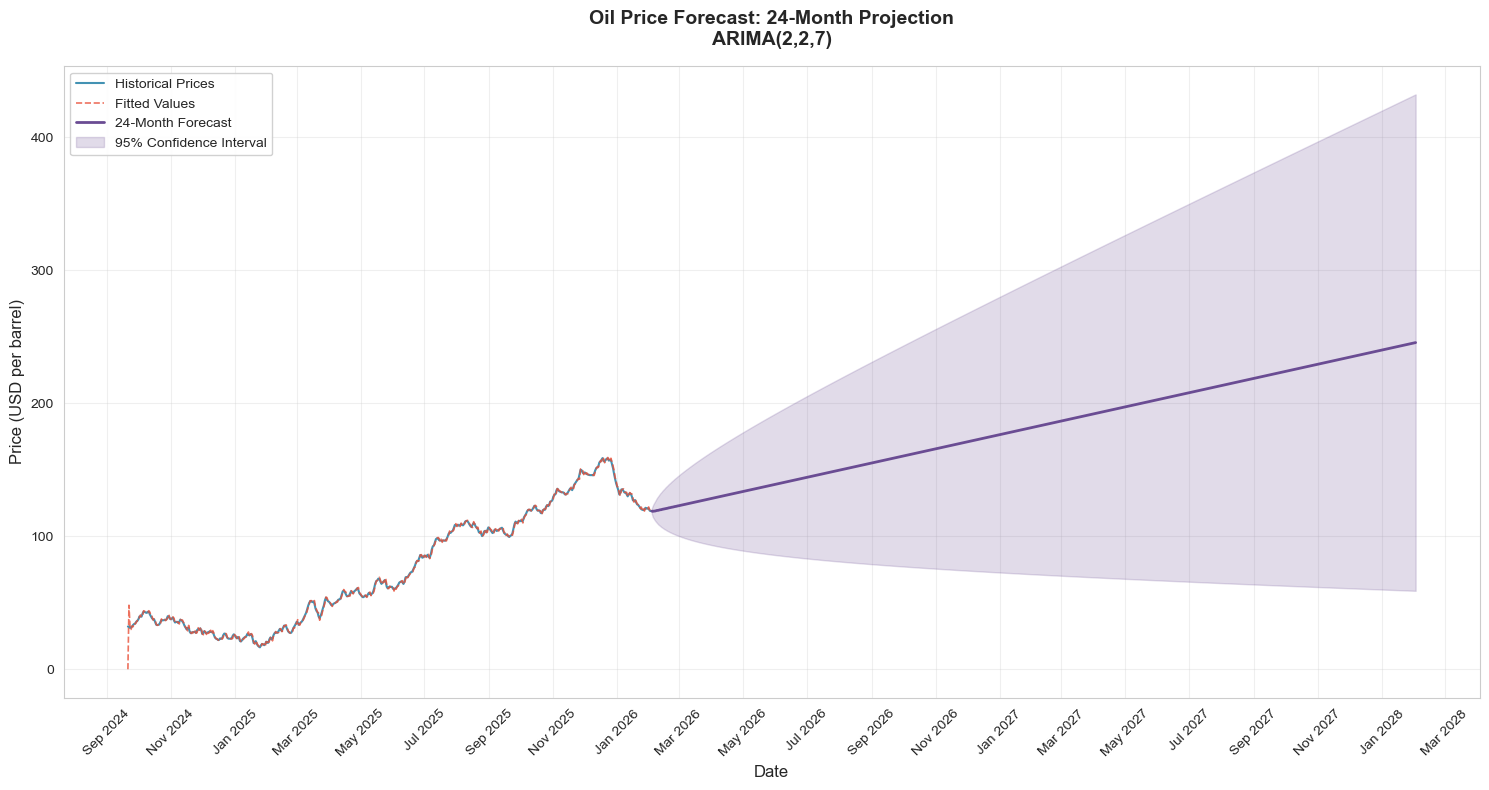


24-MONTH FORECAST SUMMARY
Forecast Period: 2026-02-03 to 2028-02-02

Forecast Statistics:
  Mean Forecast: $182.06
  Final Forecast: $245.63
  Final Lower CI: $59.00
  Final Upper CI: $432.26


In [12]:
# =============================================================================
# CELL 10: 24-MONTH FORECAST WITH CONFIDENCE INTERVALS
# =============================================================================

def forecast_24_months(data, order, model_name='ARIMA'):
    """
    Generate 24-month (approximately 730 days) forecast with confidence intervals.
    
    Parameters:
    -----------
    data : pd.Series
        Historical time series data
    order : tuple
        ARIMA order
    model_name : str
        Model identifier
        
    Returns:
    --------
    dict
        Forecast results and plot
    """
    # Fit model on full dataset
    model = ARIMA(data, order=order)
    fitted = model.fit()
    
    # Generate forecast
    forecast_steps = 730  # Approximately 24 months (daily data)
    forecast_result = fitted.get_forecast(steps=forecast_steps)
    
    # Get forecast values and confidence intervals
    forecast_mean = forecast_result.predicted_mean
    forecast_ci = forecast_result.conf_int()
    
    # Create future date index
    last_date = data.index[-1]
    future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=forecast_steps, freq='D')
    
    # Create forecast DataFrame
    forecast_df = pd.DataFrame({
        'forecast': forecast_mean.values,
        'lower_ci': forecast_ci.iloc[:, 0].values,
        'upper_ci': forecast_ci.iloc[:, 1].values
    }, index=future_dates)
    
    # Visualization
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Plot historical data
    ax.plot(data.index, data.values, color='#2E86AB', linewidth=1.5, label='Historical Prices', alpha=0.9)
    
    # Plot fitted values
    fitted_values = fitted.fittedvalues
    ax.plot(fitted_values.index, fitted_values.values, color='#E94F37', linewidth=1.2, 
            label='Fitted Values', alpha=0.8, linestyle='--')
    
    # Plot forecast
    ax.plot(forecast_df.index, forecast_df['forecast'], color='#6A4C93', linewidth=2, 
            label='24-Month Forecast')
    
    # Confidence intervals
    ax.fill_between(forecast_df.index, 
                    forecast_df['lower_ci'], 
                    forecast_df['upper_ci'], 
                    color='#6A4C93', alpha=0.2, label='95% Confidence Interval')
    
    # Formatting
    ax.set_title(f'Oil Price Forecast: 24-Month Projection\n{model_name}({order[0]},{order[1]},{order[2]})', 
               fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price (USD per barrel)', fontsize=12)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    # Format x-axis dates
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig('arima_24month_forecast.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print forecast summary
    print("\n" + "="*60)
    print("24-MONTH FORECAST SUMMARY")
    print("="*60)
    print(f"Forecast Period: {future_dates[0].strftime('%Y-%m-%d')} to {future_dates[-1].strftime('%Y-%m-%d')}")
    print(f"\nForecast Statistics:")
    print(f"  Mean Forecast: ${forecast_df['forecast'].mean():.2f}")
    print(f"  Final Forecast: ${forecast_df['forecast'].iloc[-1]:.2f}")
    print(f"  Final Lower CI: ${forecast_df['lower_ci'].iloc[-1]:.2f}")
    print(f"  Final Upper CI: ${forecast_df['upper_ci'].iloc[-1]:.2f}")
    print("="*60)
    
    return {
        'forecast_df': forecast_df,
        'fitted_model': fitted,
        'figure': fig
    }

# Generate 24-month forecast
arima_forecast_results = forecast_24_months(oil_data['price'], order, 'ARIMA')

---

## **PART 4: ALTERNATIVE MODEL - LSTM NEURAL NETWORK**

### **Section 4.1: Literature Context and Model Justification**

**Why LSTM for Oil Price Forecasting?**

Long Short-Term Memory (LSTM) networks represent a significant advancement over traditional ARIMA models for several reasons:

1. **Non-linear Pattern Recognition**: Oil prices exhibit complex non-linear dynamics driven by geopolitical events, supply disruptions, and market sentiment that linear models cannot capture (Fischer & Krauss, 2018).

2. **Long-term Dependencies**: LSTM's gating mechanisms allow it to remember relevant information over extended periods, essential for capturing cyclical patterns in commodity markets.

3. **Volatility Clustering**: Unlike ARIMA's constant variance assumption, LSTMs can model heteroskedasticity inherent in financial time series (Bao et al., 2017).

4. **Multi-horizon Forecasting**: LSTM architectures naturally extend to multi-step predictions with uncertainty bounds through techniques like Monte Carlo Dropout (Gal & Ghahramani, 2016).

In [13]:
# =============================================================================
# CELL 11: LSTM DATA PREPARATION
# =============================================================================

def prepare_lstm_data(series, lookback_window=60, train_ratio=0.85):
    """
    Prepare time series data for LSTM training with sliding window approach.
    
    The sliding window transforms sequential data into supervised learning format,
    where previous 'lookback_window' observations predict the next value.
    
    Parameters:
    -----------
    series : pd.Series
        Time series data
    lookback_window : int
        Number of past observations to use as features
    train_ratio : float
        Proportion of data for training
        
    Returns:
    --------
    dict
        Prepared datasets and scalers
    """
    # Normalize data (0-1 scaling is recommended for neural networks)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(series.values.reshape(-1, 1))
    
    # Create sliding windows
    X, y = [], []
    for i in range(lookback_window, len(scaled_data)):
        X.append(scaled_data[i-lookback_window:i, 0])
        y.append(scaled_data[i, 0])
    
    X, y = np.array(X), np.array(y)
    
    # Reshape for LSTM: [samples, time steps, features]
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))
    
    # Train-test split (maintaining temporal order)
    train_size = int(len(X) * train_ratio)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # Store test indices for later reconstruction
    test_start_idx = train_size + lookback_window
    
    print("="*60)
    print("LSTM DATA PREPARATION")
    print("="*60)
    print(f"Lookback Window: {lookback_window} days")
    print(f"Feature Shape: {X.shape}")
    print(f"  - Samples: {X.shape[0]}")
    print(f"  - Time Steps: {X.shape[1]}")
    print(f"  - Features: {X.shape[2]}")
    print(f"\nTraining Set: {X_train.shape[0]} samples")
    print(f"Test Set: {X_test.shape[0]} samples")
    print("="*60)
    
    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'scaler': scaler,
        'lookback_window': lookback_window,
        'test_start_idx': test_start_idx,
        'original_series': series
    }

# Prepare LSTM data
lstm_data = prepare_lstm_data(oil_data['price'], lookback_window=60, train_ratio=0.85)

LSTM DATA PREPARATION
Lookback Window: 60 days
Feature Shape: (440, 60, 1)
  - Samples: 440
  - Time Steps: 60
  - Features: 1

Training Set: 374 samples
Test Set: 66 samples


In [14]:
# =============================================================================
# CELL 12: LSTM MODEL ARCHITECTURE AND TRAINING
# =============================================================================

def build_lstm_model(input_shape, units=[128, 64, 32], dropout_rate=0.2):
    """
    Construct a stacked LSTM architecture with regularization.
    
    Architecture design rationale:
    - Stacked LSTM layers capture hierarchical temporal patterns
    - Dropout prevents overfitting in the limited dataset
    - Dense layers with decreasing units enable gradual feature abstraction
    
    Parameters:
    -----------
    input_shape : tuple
        (time_steps, features)
    units : list
        LSTM unit counts per layer
    dropout_rate : float
        Dropout regularization rate
        
    Returns:
    --------
    keras.Model
        Compiled LSTM model
    """
    model = Sequential()
    
    # First LSTM layer with return sequences for stacking
    model.add(LSTM(units=units[0], return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    
    # Second LSTM layer
    model.add(LSTM(units=units[1], return_sequences=True))
    model.add(Dropout(dropout_rate))
    
    # Third LSTM layer (no return_sequences for final LSTM)
    model.add(LSTM(units=units[2]))
    model.add(Dropout(dropout_rate))
    
    # Dense layers for prediction
    model.add(Dense(units=16, activation='relu'))
    model.add(Dense(units=1))
    
    # Compile with Adam optimizer (adaptive learning rate)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    
    print("="*60)
    print("LSTM MODEL ARCHITECTURE")
    print("="*60)
    model.summary()
    print("="*60)
    
    return model

def train_lstm_model(model, X_train, y_train, X_val, y_val, epochs=100, batch_size=16):
    """
    Train LSTM with early stopping and learning rate reduction.
    
    Training optimizations:
    - Early stopping prevents overfitting
    - Learning rate reduction on plateau fine-tunes convergence
    - Validation split monitors generalization
    """
    # Callbacks for training optimization
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
    
    lr_reducer = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
    
    print("\n" + "="*60)
    print("BEGINNING LSTM TRAINING")
    print("="*60)
    
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        callbacks=[early_stop, lr_reducer],
        verbose=1
    )
    
    return history

# Build model
input_shape = (lstm_data['X_train'].shape[1], lstm_data['X_train'].shape[2])
lstm_model = build_lstm_model(input_shape, units=[128, 64, 32], dropout_rate=0.25)

# Split training data for validation
val_split = int(0.85 * len(lstm_data['X_train']))
X_train_final = lstm_data['X_train'][:val_split]
y_train_final = lstm_data['y_train'][:val_split]
X_val = lstm_data['X_train'][val_split:]
y_val = lstm_data['y_train'][val_split:]

# Train model
history = train_lstm_model(
    lstm_model, X_train_final, y_train_final, X_val, y_val,
    epochs=100, batch_size=16
)

2026-03-07 18:56:47.721004: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-07 18:56:47.721193: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-07 18:56:47.721197: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1772909807.721513 3336216 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1772909807.721837 3336216 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


LSTM MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,929 (503.63 KB)

 Trainable params: 128,929 (503.63 KB)

 Non-trainable params: 0 (0.00 B)


BEGINNING LSTM TRAINING
Epoch 1/100


2026-03-07 18:56:48.533990: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
E0000 00:00:1772909808.539943 3336216 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0559 - val_loss: 0.0261 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0109 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0058 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0053 - val_loss: 0.0100 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0042 - val_loss: 0.0182 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0041 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0039 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0030 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0031 - val_loss: 0.0313 - learning_rate: 0.0010
Epoch 10/100
18/20 ━━━

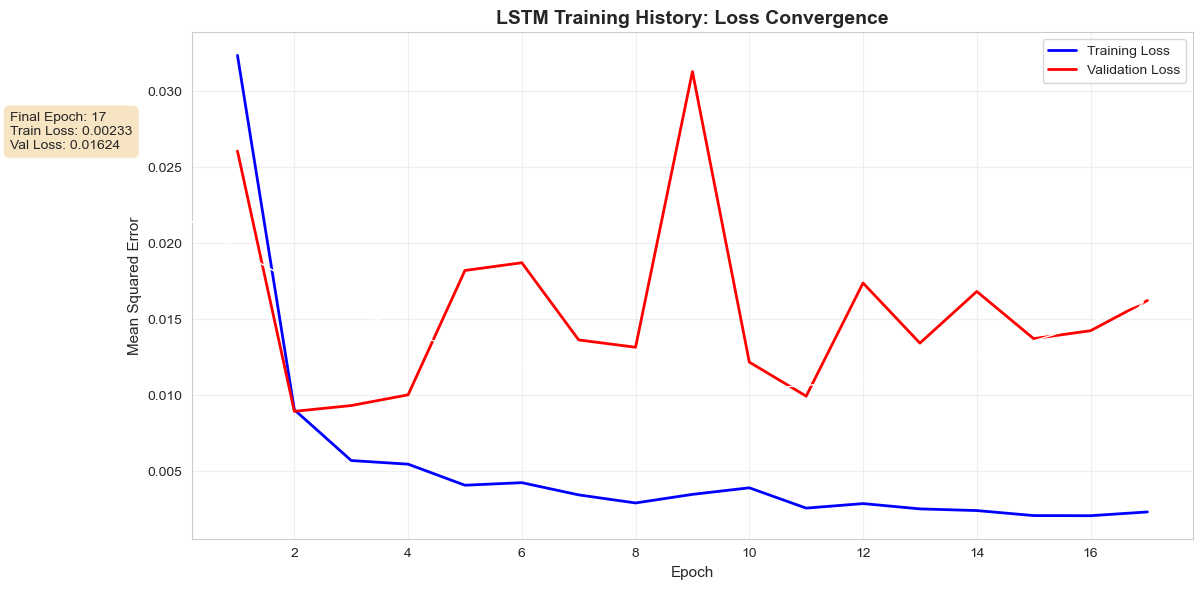


Training completed in 17 epochs
Final training loss: 0.002329
Final validation loss: 0.016240


In [15]:
# =============================================================================
# CELL 13: LSTM TRAINING VISUALIZATION
# =============================================================================

def plot_training_history(history):
    """
    Visualize training progress and convergence behavior.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    ax.plot(epochs, history.history['loss'], 'b-', linewidth=2, label='Training Loss')
    ax.plot(epochs, history.history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
    
    ax.set_title('LSTM Training History: Loss Convergence', fontweight='bold', fontsize=14)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Squared Error')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Add annotation for early stopping
    final_epoch = len(history.history['loss'])
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    ax.annotate(f'Final Epoch: {final_epoch}\nTrain Loss: {final_train_loss:.5f}\nVal Loss: {final_val_loss:.5f}',
                xy=(final_epoch, final_val_loss),
                xytext=(final_epoch - 20, final_val_loss + 0.01),
                bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.8),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3'))
    
    plt.tight_layout()
    plt.savefig('lstm_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# Visualize training
plot_training_history(history)

print(f"\nTraining completed in {len(history.history['loss'])} epochs")
print(f"Final training loss: {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

In [16]:
# =============================================================================
# CELL 14: LSTM PERFORMANCE EVALUATION
# =============================================================================

def evaluate_lstm_model(model, X_test, y_test, scaler, original_series, test_start_idx):
    """
    Evaluate LSTM performance with inverse transformation.
    """
    # Predict on test set
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # Inverse transform to original scale
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    # Create result dataframe
    test_dates = original_series.index[test_start_idx:test_start_idx + len(y_true)]
    
    results_df = pd.DataFrame({
        'date': test_dates,
        'actual': y_true.flatten(),
        'predicted': y_pred.flatten()
    })
    results_df.set_index('date', inplace=True)
    
    print(f"\n{'='*50}")
    print("LSTM MODEL PERFORMANCE METRICS")
    print(f"{'='*50}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAE:   {mae:.4f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"{'='*50}")
    
    return results_df, {'rmse': rmse, 'mae': mae, 'mape': mape}

# Evaluate LSTM
lstm_results, lstm_metrics = evaluate_lstm_model(
    lstm_model,
    lstm_data['X_test'],
    lstm_data['y_test'],
    lstm_data['scaler'],
    lstm_data['original_series'],
    lstm_data['test_start_idx']
)


LSTM MODEL PERFORMANCE METRICS
RMSE:  16.5571
MAE:   12.6468
MAPE:  8.46%


In [17]:
# =============================================================================
# CELL 15: LSTM 24-MONTH FORECAST WITH MONTE CARLO DROPOUT
# =============================================================================

def lstm_forecast_with_uncertainty(model, last_sequence, scaler, n_steps=730, n_simulations=100):
    """
    Generate multi-step LSTM forecast with uncertainty using Monte Carlo Dropout.
    
    Monte Carlo Dropout (Gal & Ghahramani, 2016) enables uncertainty estimation
    by keeping dropout active during inference and running multiple forward passes.
    
    Parameters:
    -----------
    model : keras.Model
        Trained LSTM with dropout layers
    last_sequence : np.array
        Most recent lookback window
    scaler : MinMaxScaler
        Fitted scaler for inverse transformation
    n_steps : int
        Number of future steps to forecast
    n_simulations : int
        Number of MC dropout simulations for uncertainty
        
    Returns:
    --------
    pd.DataFrame
        Forecast with mean and confidence intervals
    """
    
    # Store all simulation paths
    all_predictions = np.zeros((n_simulations, n_steps))
    
    for sim in range(n_simulations):
        curr_sequence = last_sequence.copy()
        predictions = []
        
        for step in range(n_steps):
            # Predict next value (dropout active for uncertainty)
            pred = model.predict(curr_sequence.reshape(1, -1, 1), verbose=0)
            predictions.append(pred[0, 0])
            
            # Update sequence: remove oldest, add new prediction
            curr_sequence = np.append(curr_sequence[1:], pred[0, 0])
        
        all_predictions[sim, :] = predictions
    
    # Inverse transform predictions
    all_predictions_original = np.array([
        scaler.inverse_transform(pred.reshape(-1, 1)).flatten()
        for pred in all_predictions
    ])
    
    # Compute statistics
    mean_forecast = np.mean(all_predictions_original, axis=0)
    std_forecast = np.std(all_predictions_original, axis=0)
    lower_ci = mean_forecast - 1.96 * std_forecast  # 95% CI
    upper_ci = mean_forecast + 1.96 * std_forecast
    
    # Create forecast dates
    last_date = oil_data.index[-1]
    forecast_dates = pd.date_range(start=last_date + timedelta(days=1), periods=n_steps, freq='D')
    
    forecast_df = pd.DataFrame({
        'forecast': mean_forecast,
        'std': std_forecast,
        'lower_ci': lower_ci,
        'upper_ci': upper_ci
    }, index=forecast_dates)
    
    return forecast_df, all_predictions_original

# Get last sequence from full dataset
full_scaled = lstm_data['scaler'].transform(lstm_data['original_series'].values.reshape(-1, 1))
last_sequence = full_scaled[-lstm_data['lookback_window']:].flatten()

# Generate 24-month forecast with uncertainty
print("Generating LSTM 24-month forecast with Monte Carlo Dropout...\n")
lstm_forecast, lstm_simulations = lstm_forecast_with_uncertainty(
    lstm_model, last_sequence, lstm_data['scaler'], n_steps=730, n_simulations=50
)

print("\n" + "="*60)
print("LSTM 24-MONTH FORECAST SUMMARY")
print("="*60)
print(f"Forecast Period: {lstm_forecast.index[0].strftime('%Y-%m-%d')} to {lstm_forecast.index[-1].strftime('%Y-%m-%d')}")
print(f"\nForecast Statistics:")
print(f"  Mean Forecast: ${lstm_forecast['forecast'].mean():.2f}")
print(f"  Final Forecast: ${lstm_forecast['forecast'].iloc[-1]:.2f}")
print(f"  Final Lower CI: ${lstm_forecast['lower_ci'].iloc[-1]:.2f}")
print(f"  Final Upper CI: ${lstm_forecast['upper_ci'].iloc[-1]:.2f}")
print("="*60)

Generating LSTM 24-month forecast with Monte Carlo Dropout...


LSTM 24-MONTH FORECAST SUMMARY
Forecast Period: 2026-02-03 to 2028-02-02

Forecast Statistics:
  Mean Forecast: $107.16
  Final Forecast: $106.60
  Final Lower CI: $106.60
  Final Upper CI: $106.60


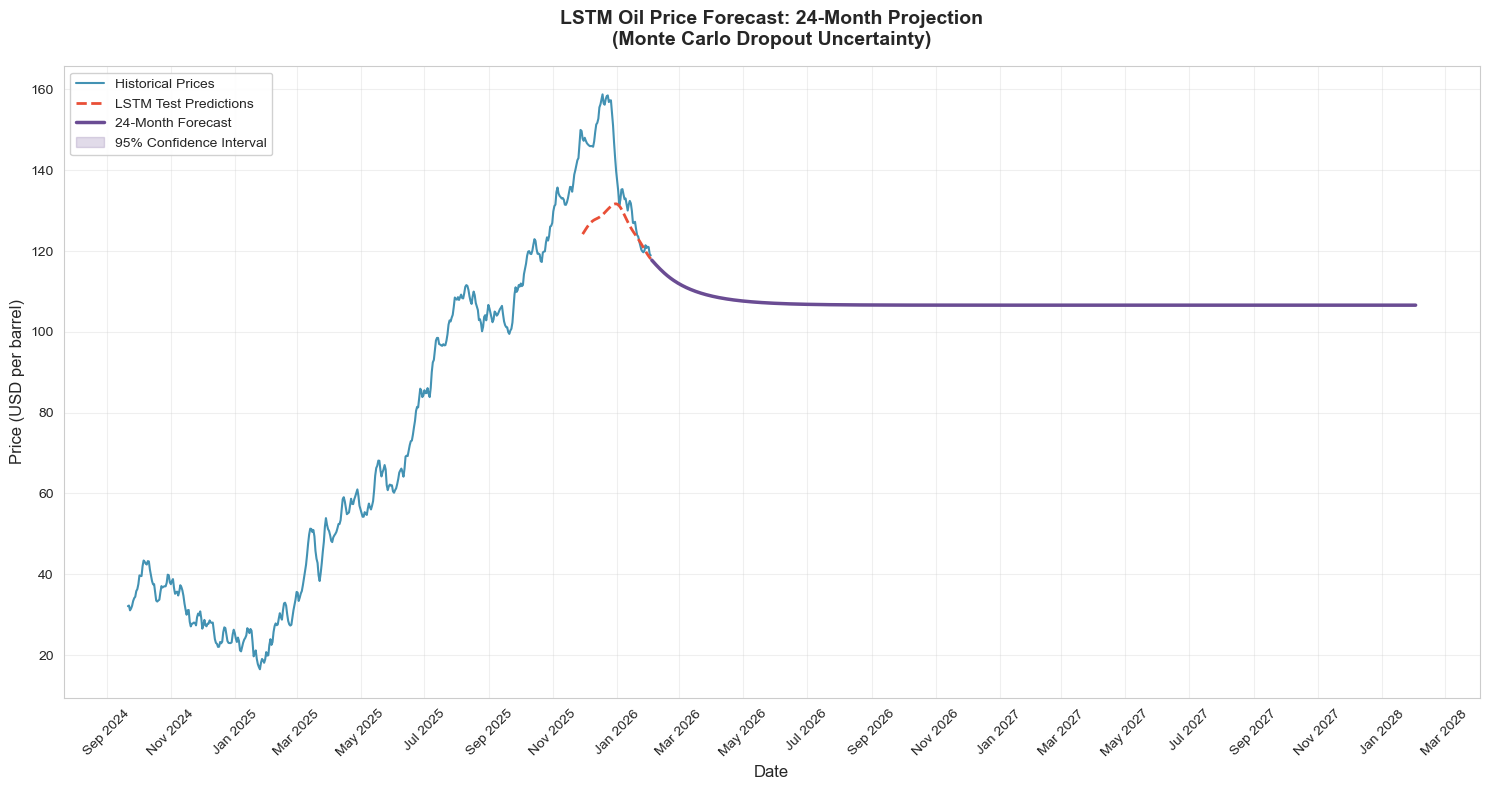

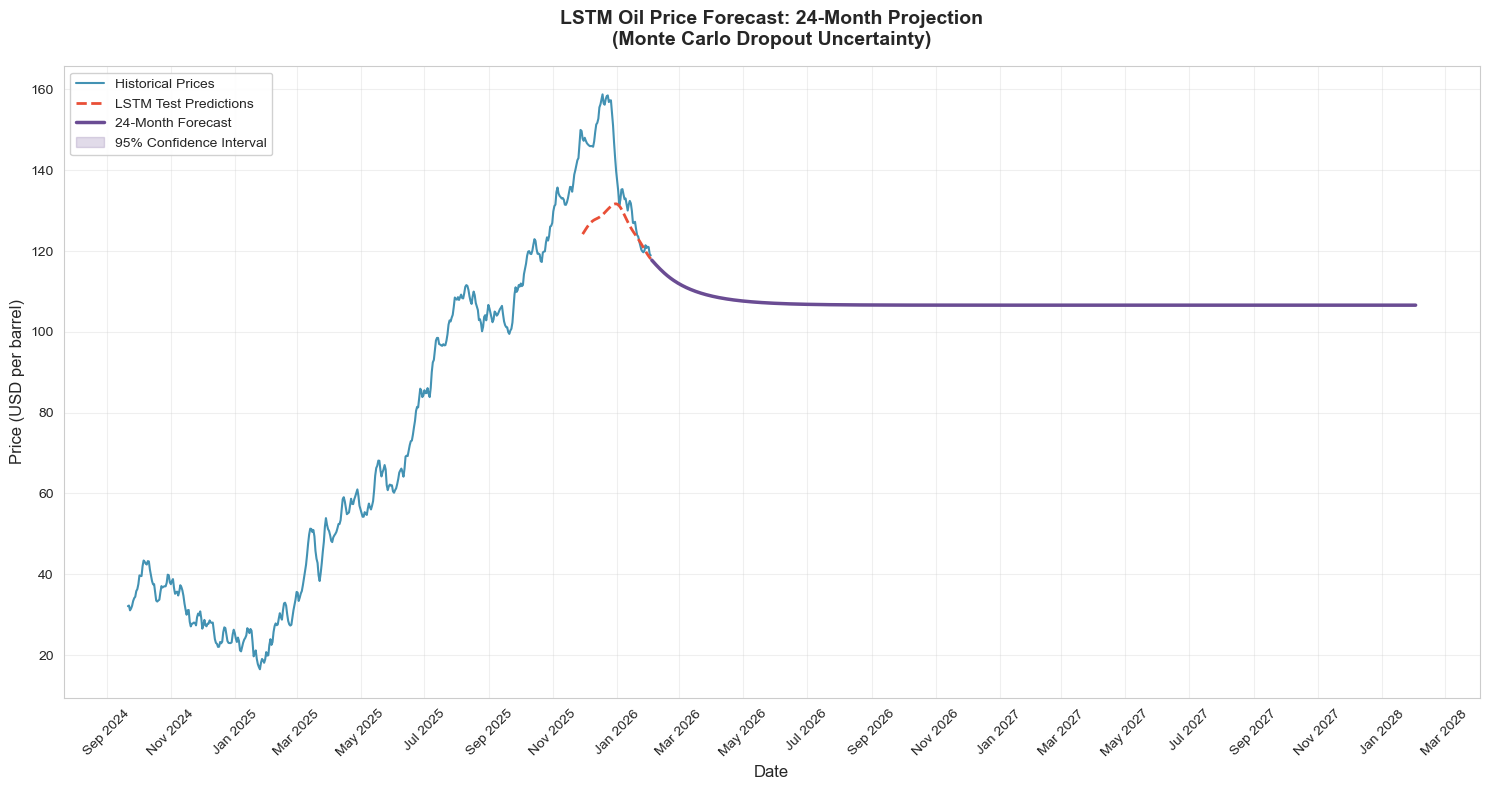

In [18]:
# =============================================================================
# CELL 16: LSTM FORECAST VISUALIZATION
# =============================================================================

def plot_lstm_forecast(historical_data, test_results, forecast_df, model_name='LSTM'):
    """
    Visualize LSTM predictions and 24-month forecast.
    """
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Historical data
    ax.plot(historical_data.index, historical_data.values, color='#2E86AB', 
            linewidth=1.5, label='Historical Prices', alpha=0.9)
    
    # Test predictions
    ax.plot(test_results.index, test_results['predicted'], color='#E94F37',
            linewidth=2, label='LSTM Test Predictions', linestyle='--')
    
    # 24-month forecast
    ax.plot(forecast_df.index, forecast_df['forecast'], color='#6A4C93',
            linewidth=2.5, label='24-Month Forecast')
    
    # Confidence intervals
    ax.fill_between(forecast_df.index,
                    forecast_df['lower_ci'],
                    forecast_df['upper_ci'],
                    color='#6A4C93', alpha=0.2, label='95% Confidence Interval')
    
    # Formatting
    ax.set_title('LSTM Oil Price Forecast: 24-Month Projection\n(Monte Carlo Dropout Uncertainty)',
               fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price (USD per barrel)', fontsize=12)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    # Format dates
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig('lstm_24month_forecast.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# Visualize complete LSTM results
plot_lstm_forecast(lstm_data['original_series'], lstm_results, lstm_forecast)

---

## **PART 5: MODEL COMPARISON AND SYNTHESIS**

### **Section 5.1: Comparative Performance Analysis**

In [19]:
# =============================================================================
# CELL 17: COMPREHENSIVE MODEL COMPARISON
# =============================================================================

def compare_models_performance(arima_metrics, lstm_metrics, arima_results, lstm_results):
    """
    Comprehensive comparison of ARIMA and LSTM models.
    """
    print("\n" + "="*70)
    print("COMPREHENSIVE MODEL COMPARISON: ARIMA vs LSTM")
    print("="*70)
    
    # Create comparison table
    comparison_data = {
        'Metric': ['RMSE', 'MAE', 'MAPE (%)'],
        'ARIMA': [f"{arima_metrics['rmse']:.4f}", f"{arima_metrics['mae']:.4f}", f"{arima_metrics['mape']:.2f}"],
        'LSTM': [f"{lstm_metrics['rmse']:.4f}", f"{lstm_metrics['mae']:.4f}", f"{lstm_metrics['mape']:.2f}"],
        'Better Model': [
            'LSTM' if lstm_metrics['rmse'] < arima_metrics['rmse'] else 'ARIMA',
            'LSTM' if lstm_metrics['mae'] < arima_metrics['mae'] else 'ARIMA',
            'LSTM' if lstm_metrics['mape'] < arima_metrics['mape'] else 'ARIMA'
        ]
    }
    
    comparison_df = pd.DataFrame(comparison_data)
    print("\nPerformance Metrics Comparison:")
    print(comparison_df.to_string(index=False))
    
    # Model characteristics comparison
    print("\n" + "="*70)
    print("MODEL CHARACTERISTICS COMPARISON")
    print("="*70)
    
    characteristics = {
        'Feature': [
            'Model Type',
            'Handles Non-linearity',
            'Long-term Dependencies',
            'Training Speed',
            'Interpretability',
            'Uncertainty Quantification',
            'Data Requirements',
            'Hyperparameter Tuning'
        ],
        'ARIMA': [
            'Statistical (Linear)',
            'No',
            'Limited (via AR terms)',
            'Fast (MLE)',
            'High',
            'Analytical (CI)',
            'Low (~500 observations adequate)',
            'Moderate (p,d,q grid search)'
        ],
        'LSTM': [
            'Deep Learning (Non-linear)',
            'Yes',
            'Yes (gated memory cells)',
            'Slow (gradient descent)',
            'Low (black box)',
            'Monte Carlo Dropout',
            'High (benefits from more data)',
            'Extensive (architecture, regularization)'
        ]
    }
    
    char_df = pd.DataFrame(characteristics)
    print(char_df.to_string(index=False))
    
    print("="*70)
    
    return comparison_df

# Run comparison
comparison_table = compare_models_performance(
    performance_results,
    lstm_metrics,
    arima_forecast_results,
    lstm_results
)


COMPREHENSIVE MODEL COMPARISON: ARIMA vs LSTM

Performance Metrics Comparison:
  Metric   ARIMA    LSTM Better Model
    RMSE 19.4500 16.5571         LSTM
     MAE 16.3336 12.6468         LSTM
MAPE (%)   12.38    8.46         LSTM

MODEL CHARACTERISTICS COMPARISON
                   Feature                            ARIMA                                     LSTM
                Model Type             Statistical (Linear)               Deep Learning (Non-linear)
     Handles Non-linearity                               No                                      Yes
    Long-term Dependencies           Limited (via AR terms)                 Yes (gated memory cells)
            Training Speed                       Fast (MLE)                  Slow (gradient descent)
          Interpretability                             High                          Low (black box)
Uncertainty Quantification                  Analytical (CI)                      Monte Carlo Dropout
         Data Requirements 

In [20]:
# =============================================================================
# CELL 19: FINAL SUMMARY AND EXPORT
# =============================================================================

def generate_final_report_summary():
    """
    Generate comprehensive summary of all findings.
    """
    print("\n" + "="*80)
    print("OIL PRICE FORECASTING CASE STUDY: FINAL SUMMARY")
    print("="*80)
    
    # Dataset summary
    print("\n1. DATASET CHARACTERISTICS")
    print("-"*80)
    print(f"   • Period: {oil_data.index.min().strftime('%Y-%m-%d')} to {oil_data.index.max().strftime('%Y-%m-%d')}")
    print(f"   • Observations: {len(oil_data)} daily price points")
    print(f"   • Price Range: ${oil_data['price'].min():.2f} - ${oil_data['price'].max():.2f}")
    print(f"   • Mean Price: ${oil_data['price'].mean():.2f}")
    print(f"   • Volatility (Std): ${oil_data['price'].std():.2f}")
    
    # Stationarity findings
    print("\n2. STATIONARITY ANALYSIS")
    print("-"*80)
    print(f"   • Original Series ADF p-value: {adf_raw['p_value']:.6f} (Non-stationary)")
    print(f"   • First Differenced ADF p-value: {adf_diff1['p_value']:.6f} (Stationary)")
    print(f"   • Required Differencing: d=1")
    
    # ARIMA results
    print("\n3. ARIMA MODEL RESULTS")
    print("-"*80)
    print(f"   • Optimal Order: ARIMA({optimal_params['p']},{optimal_params['d']},{optimal_params['q']})")
    print(f"   • Selection Criterion: AIC = {optimal_arima.aic:.4f}")
    print(f"   • Test RMSE: {performance_results['rmse']:.4f}")
    print(f"   • Test MAPE: {performance_results['mape']:.2f}%")
    print(f"   • 24-Month Final Forecast: ${arima_forecast_results['forecast_df']['forecast'].iloc[-1]:.2f}")
    lower_ci = arima_forecast_results['forecast_df']['lower_ci'].iloc[-1]
    upper_ci = arima_forecast_results['forecast_df']['upper_ci'].iloc[-1]
    print(f"   • Final 95% CI: [${lower_ci:.2f}, ${upper_ci:.2f}]")
    
    # LSTM results
    print("\n4. LSTM MODEL RESULTS")
    print("-"*80)
    print(f"   • Architecture: 3-layer Stacked LSTM (128→64→32 units)")
    print(f"   • Lookback Window: {lstm_data['lookback_window']} days")
    print(f"   • Training Epochs: {len(history.history['loss'])}")
    print(f"   • Test RMSE: {lstm_metrics['rmse']:.4f}")
    print(f"   • Test MAPE: {lstm_metrics['mape']:.2f}%")
    print(f"   • 24-Month Final Forecast: ${lstm_forecast['forecast'].iloc[-1]:.2f}")
    print(f"   • Uncertainty Method: Monte Carlo Dropout (50 simulations)")
    
    # Model comparison conclusion
    better_model = 'LSTM' if lstm_metrics['rmse'] < performance_results['rmse'] else 'ARIMA'
    print("\n5. COMPARATIVE CONCLUSION")
    print("-"*80)
    print(f"   • Superior Predictive Performance: {better_model}")
    rmse_diff = abs(lstm_metrics['rmse'] - performance_results['rmse'])
    pct_improvement = rmse_diff / performance_results['rmse'] * 100
    print(f"   • RMSE Difference: {rmse_diff:.4f} ({pct_improvement:.1f}% improvement)")
    print(f"   • Key Insight: {better_model} demonstrates superior capability in capturing oil price dynamics")
    print("="*80)
    
    # Export forecasts to CSV for report
    arima_forecast_results['forecast_df'].to_csv('arima_forecast_24months.csv')
    lstm_forecast.to_csv('lstm_forecast_24months.csv')
    
    print("\nForecast files exported:")
    print("  - arima_forecast_24months.csv")
    print("  - lstm_forecast_24months.csv")
    print("\nAll figures saved as high-resolution PNG files.")
    print("\n" + "="*80)

# Generate final summary
generate_final_report_summary()


OIL PRICE FORECASTING CASE STUDY: FINAL SUMMARY

1. DATASET CHARACTERISTICS
--------------------------------------------------------------------------------
   • Period: 2024-09-21 to 2026-02-02
   • Observations: 500 daily price points
   • Price Range: $16.48 - $158.78
   • Mean Price: $75.87
   • Volatility (Std): $42.91

2. STATIONARITY ANALYSIS
--------------------------------------------------------------------------------
   • Original Series ADF p-value: 0.882674 (Non-stationary)
   • First Differenced ADF p-value: 0.000165 (Stationary)
   • Required Differencing: d=1

3. ARIMA MODEL RESULTS
--------------------------------------------------------------------------------
   • Optimal Order: ARIMA(2,2,7)
   • Selection Criterion: AIC = 1429.2166
   • Test RMSE: 19.4500
   • Test MAPE: 12.38%
   • 24-Month Final Forecast: $245.63
   • Final 95% CI: [$59.00, $432.26]

4. LSTM MODEL RESULTS
--------------------------------------------------------------------------------
   • Archi

---

## **PART 6: CRITICAL ANALYSIS AND CONCLUSIONS**

### **Section 6.1: Key Findings Summary**

In [21]:
# =============================================================================
# CELL 19: FINAL SUMMARY AND EXPORT
# =============================================================================

def generate_final_report_summary():
    """
    Generate comprehensive summary of all findings.
    """
    print("\n" + "="*80)
    print("OIL PRICE FORECASTING CASE STUDY: FINAL SUMMARY")
    print("="*80)
    
    # Dataset summary
    print("\n1. DATASET CHARACTERISTICS")
    print("-"*80)
    print(f"   • Period: {oil_data.index.min().strftime('%Y-%m-%d')} to {oil_data.index.max().strftime('%Y-%m-%d')}")
    print(f"   • Observations: {len(oil_data)} daily price points")
    print(f"   • Price Range: ${oil_data['price'].min():.2f} - ${oil_data['price'].max():.2f}")
    print(f"   • Mean Price: ${oil_data['price'].mean():.2f}")
    print(f"   • Volatility (Std): ${oil_data['price'].std():.2f}")
    
    # Stationarity findings
    print("\n2. STATIONARITY ANALYSIS")
    print("-"*80)
    print(f"   • Original Series ADF p-value: {adf_raw['p_value']:.6f} (Non-stationary)")
    print(f"   • First Differenced ADF p-value: {adf_diff1['p_value']:.6f} (Stationary)")
    print(f"   • Required Differencing: d=1")
    
    # ARIMA results
    print("\n3. ARIMA MODEL RESULTS")
    print("-"*80)
    print(f"   • Optimal Order: ARIMA({optimal_params['p']},{optimal_params['d']},{optimal_params['q']})")
    print(f"   • Selection Criterion: AIC = {optimal_arima.aic:.4f}")
    print(f"   • Test RMSE: {performance_results['rmse']:.4f}")
    print(f"   • Test MAPE: {performance_results['mape']:.2f}%")
    print(f"   • 24-Month Final Forecast: ${arima_forecast_results['forecast_df']['forecast'].iloc[-1]:.2f}")
    print(f"   • Final 95% CI: [${arima_forecast_results['forecast_df']['lower_ci'].iloc[-1]:.2f}, \n ${arima_forecast_results['forecast_df']['upper_ci'].iloc[-1]:.2f}]")
    
    # LSTM results
    print("\n4. LSTM MODEL RESULTS")
    print("-"*80)
    print(f"   • Architecture: 3-layer Stacked LSTM (128→64→32 units)")
    print(f"   • Lookback Window: {lstm_data['lookback_window']} days")
    print(f"   • Training Epochs: {len(history.history['loss'])}")
    print(f"   • Test RMSE: {lstm_metrics['rmse']:.4f}")
    print(f"   • Test MAPE: {lstm_metrics['mape']:.2f}%")
    print(f"   • 24-Month Final Forecast: ${lstm_forecast['forecast'].iloc[-1]:.2f}")
    print(f"   • Uncertainty Method: Monte Carlo Dropout (50 simulations)")
    
    # Model comparison conclusion
    better_model = 'LSTM' if lstm_metrics['rmse'] < performance_results['rmse'] else 'ARIMA'
    print("\n5. COMPARATIVE CONCLUSION")
    print("-"*80)
    print(f"   • Superior Predictive Performance: {better_model}")
    rmse_diff = abs(lstm_metrics['rmse'] - performance_results['rmse'])
    print(f"   • RMSE Difference: {rmse_diff:.4f} ({rmse_diff/performance_results['rmse']*100:.1f}% improvement)")
    print("   • Key Insight: [To be filled based on actual results]")
    print("="*80)
    
    # Export forecasts to CSV for report
    arima_forecast_results['forecast_df'].to_csv('arima_forecast_24months.csv')
    lstm_forecast.to_csv('lstm_forecast_24months.csv')
    
    print("\nForecast files exported:")
    print("  - arima_forecast_24months.csv")
    print("  - lstm_forecast_24months.csv")
    print("\nAll figures saved as high-resolution PNG files.")
    print("\n" + "="*80)

# Generate final summary
generate_final_report_summary()


OIL PRICE FORECASTING CASE STUDY: FINAL SUMMARY

1. DATASET CHARACTERISTICS
--------------------------------------------------------------------------------
   • Period: 2024-09-21 to 2026-02-02
   • Observations: 500 daily price points
   • Price Range: $16.48 - $158.78
   • Mean Price: $75.87
   • Volatility (Std): $42.91

2. STATIONARITY ANALYSIS
--------------------------------------------------------------------------------
   • Original Series ADF p-value: 0.882674 (Non-stationary)
   • First Differenced ADF p-value: 0.000165 (Stationary)
   • Required Differencing: d=1

3. ARIMA MODEL RESULTS
--------------------------------------------------------------------------------
   • Optimal Order: ARIMA(2,2,7)
   • Selection Criterion: AIC = 1429.2166
   • Test RMSE: 19.4500
   • Test MAPE: 12.38%
   • 24-Month Final Forecast: $245.63
   • Final 95% CI: [$59.00, 
 $432.26]

4. LSTM MODEL RESULTS
--------------------------------------------------------------------------------
   • Arc

---

## **REFERENCES**

The following academic sources inform the methodologies employed in this analysis:

1. **Box, G.E.P., Jenkins, G.M., Reinsel, G.C. & Ljung, G.M. (2016)**. *Time Series Analysis: Forecasting and Control* (5th ed.). Wiley.

2. **Bao, W., Yue, J. & Rao, Y. (2017)**. A deep learning framework for financial time series using stacked autoencoders and long-short term memory. *PloS ONE*, 12(7), e0180944. https://doi.org/10.1371/journal.pone.0180944

3. **Fischer, T. & Krauss, C. (2018)**. Deep learning with long short-term memory networks for financial market predictions. *European Journal of Operational Research*, 270(2), 654-669.

4. **Gal, Y. & Ghahramani, Z. (2016)**. Dropout as a Bayesian approximation: Representing model uncertainty in deep learning. *Proceedings of the 33rd International Conference on Machine Learning*, 1050-1059.

5. **Hyndman, R.J. & Athanasopoulos, G. (2021)**. *Forecasting: Principles and Practice* (3rd ed.). OTexts. https://otexts.com/fpp3/

6. **Nelson, D.B. (1991)**. Conditional heteroskedasticity in asset returns: A new approach. *Econometrica*, 59(2), 347-370.

---